In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/telco_clean.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [2]:
# Binary encode Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0})

# Gender
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# Contract type
df['Contract_encoded'] = df['Contract'].map({
    'Month-to-month': 0,
    'One year': 1,
    'Two year': 2
})

# Internet service
df['InternetService_encoded'] = df['InternetService'].map({
    'No': 0, 'DSL': 1, 'Fiber optic': 2
})

# Payment method
df['PaymentMethod_encoded'] = df['PaymentMethod'].map({
    'Electronic check': 0,
    'Mailed check': 1,
    'Bank transfer (automatic)': 2,
    'Credit card (automatic)': 3
})

print("Encoding done ✅")
print(df.dtypes)

Encoding done ✅
customerID                  object
gender                       int64
SeniorCitizen                int64
Partner                      int64
Dependents                   int64
tenure                       int64
PhoneService                 int64
MultipleLines                int64
InternetService             object
OnlineSecurity               int64
OnlineBackup                 int64
DeviceProtection             int64
TechSupport                  int64
StreamingTV                  int64
StreamingMovies              int64
Contract                    object
PaperlessBilling             int64
PaymentMethod               object
MonthlyCharges             float64
TotalCharges               float64
Churn                       object
Churn_binary                 int64
Contract_encoded             int64
InternetService_encoded      int64
PaymentMethod_encoded        int64
dtype: object


In [3]:
# Recency: tenure ngược lại — càng ít tháng gần đây càng "recent churn risk"
df['recency_risk'] = 1 / (df['tenure'] + 1)  # +1 tránh chia 0

# Frequency: số lượng services đang dùng
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
df['service_count'] = df[service_cols].sum(axis=1)

# Monetary: tổng giá trị khách hàng
df['monetary_value'] = df['TotalCharges']
df['monthly_to_total_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

print("=== RFM Features ===")
print(df[['recency_risk', 'service_count', 'monetary_value', 'monthly_to_total_ratio']].describe())

=== RFM Features ===
       recency_risk  service_count  monetary_value  monthly_to_total_ratio
count   7043.000000    7043.000000     7043.000000             7043.000000
mean       0.102853       3.362914     2279.734304                0.219382
std        0.147716       2.062031     2266.794470                1.880743
min        0.013699       0.000000        0.000000                0.012596
25%        0.017857       1.000000      398.550000                0.018091
50%        0.033333       3.000000     1394.550000                0.034860
75%        0.100000       5.000000     3786.600000                0.114266
max        1.000000       8.000000     8684.800000               80.850000


In [4]:
# Charge per tenure month
df['charge_per_month'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# Customer value score (CLV proxy)
df['clv_proxy'] = df['TotalCharges'] * (1 - df['recency_risk'])

# High value flag
df['is_high_value'] = (df['clv_proxy'] > df['clv_proxy'].quantile(0.75)).astype(int)

# Contract stability score
df['contract_stability'] = df['Contract_encoded'] * df['tenure']

# Digital engagement (paperless + auto payment)
df['digital_engagement'] = (
    df['PaperlessBilling'] +
    df['PaymentMethod_encoded'].apply(lambda x: 1 if x >= 2 else 0)
)

print("=== Behavioral Features ===")
print(df[['charge_per_month', 'clv_proxy', 'is_high_value',
          'contract_stability', 'digital_engagement']].describe())

=== Behavioral Features ===
       charge_per_month    clv_proxy  is_high_value  contract_stability  \
count       7043.000000  7043.000000    7043.000000         7043.000000   
mean           5.770645  2220.743515       0.250035           36.101661   
std            8.722435  2243.496916       0.433064           50.598114   
min            0.264384     0.000000       0.000000            0.000000   
25%            1.250000   354.927083       0.000000            0.000000   
50%            2.075926  1350.426316       0.000000            0.000000   
75%            5.946429  3722.166071       0.500000           62.000000   
max           80.850000  8565.830137       1.000000          144.000000   

       digital_engagement  
count         7043.000000  
mean             1.027545  
std              0.689378  
min              0.000000  
25%              1.000000  
50%              1.000000  
75%              2.000000  
max              2.000000  


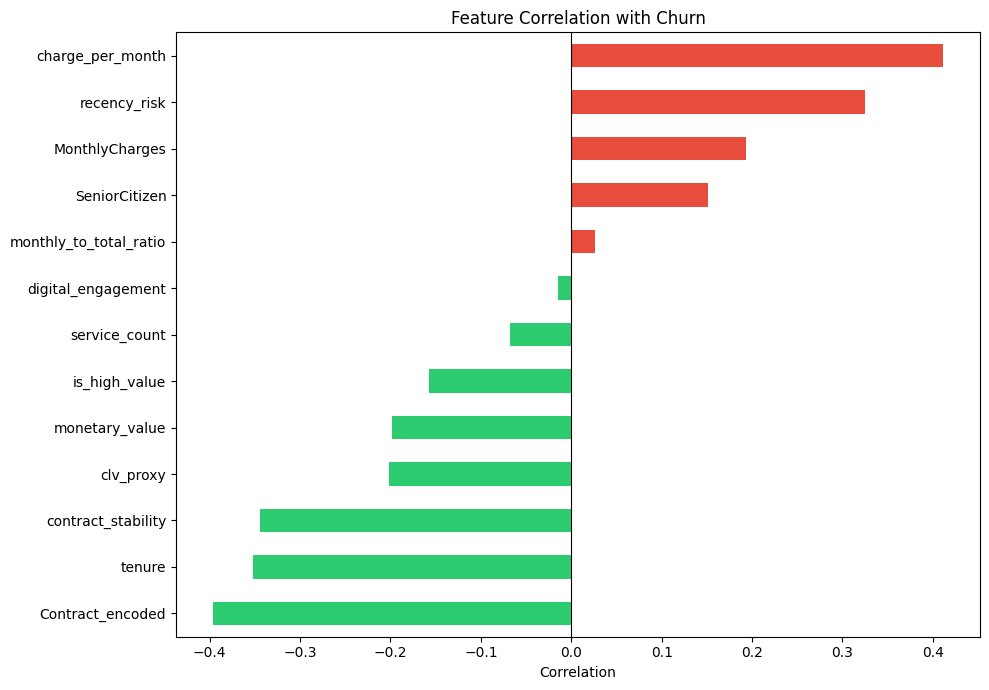


Top positive (churn risk):
monthly_to_total_ratio    0.026299
SeniorCitizen             0.150889
MonthlyCharges            0.193356
recency_risk              0.325459
charge_per_month          0.411756
Name: Churn_binary, dtype: float64

Top negative (churn protection):
Contract_encoded     -0.396713
tenure               -0.352229
contract_stability   -0.344033
clv_proxy            -0.201373
monetary_value       -0.198324
Name: Churn_binary, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = ['recency_risk', 'service_count', 'monetary_value',
                'monthly_to_total_ratio', 'charge_per_month', 'clv_proxy',
                'is_high_value', 'contract_stability', 'digital_engagement',
                'tenure', 'MonthlyCharges', 'SeniorCitizen', 'Contract_encoded']

corr_with_churn = df[feature_cols + ['Churn_binary']].corr()['Churn_binary'].drop('Churn_binary')
corr_with_churn = corr_with_churn.sort_values()

plt.figure(figsize=(10, 7))
colors = ['#E74C3C' if x > 0 else '#2ECC71' for x in corr_with_churn]
corr_with_churn.plot(kind='barh', color=colors)
plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.savefig('../data/processed/feature_correlation.png', dpi=150)
plt.show()

print("\nTop positive (churn risk):")
print(corr_with_churn.tail(5))
print("\nTop negative (churn protection):")
print(corr_with_churn.head(5))

In [6]:
# Drop columns không cần
drop_cols = ['customerID', 'Churn', 'Contract', 'InternetService',
             'PaymentMethod', 'gender']

df_features = df.drop(columns=drop_cols)

df_features.to_csv('../data/processed/features.csv', index=False)

print(f"Feature set saved ✅")
print(f"Shape: {df_features.shape}")
print(f"Features: {df_features.columns.tolist()}")

Feature set saved ✅
Shape: (7043, 28)
Features: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn_binary', 'Contract_encoded', 'InternetService_encoded', 'PaymentMethod_encoded', 'recency_risk', 'service_count', 'monetary_value', 'monthly_to_total_ratio', 'charge_per_month', 'clv_proxy', 'is_high_value', 'contract_stability', 'digital_engagement']
